# Mathematical Limitations of Machine Learning in Astronomy
## The Curse of Dimensionality & Measure Concentration in Spectroscopy

### Theoretical Framework
In astronomical spectroscopy, observations often yield high-dimensional feature spaces ($D \gg 1000$ wavelengths). As $D$ increases, the volume of the space grows exponentially, causing data points to become extremely sparse. 

Mathematically, under the **Concentration of Measure** phenomenon, the contrast between the distance to the nearest neighbor and the distance to the farthest neighbor approaches zero as dimensionality goes to infinity:
$$ \lim_{D \to \infty} \frac{\mathcal{D}_{\max} - \mathcal{D}_{\min}}{\mathcal{D}_{\min}} = 0 $$

This severely restricts distance-based clustering and classification algorithms (e.g., KNN, Support Vector Machines with RBF kernels), leading to geometric instability.


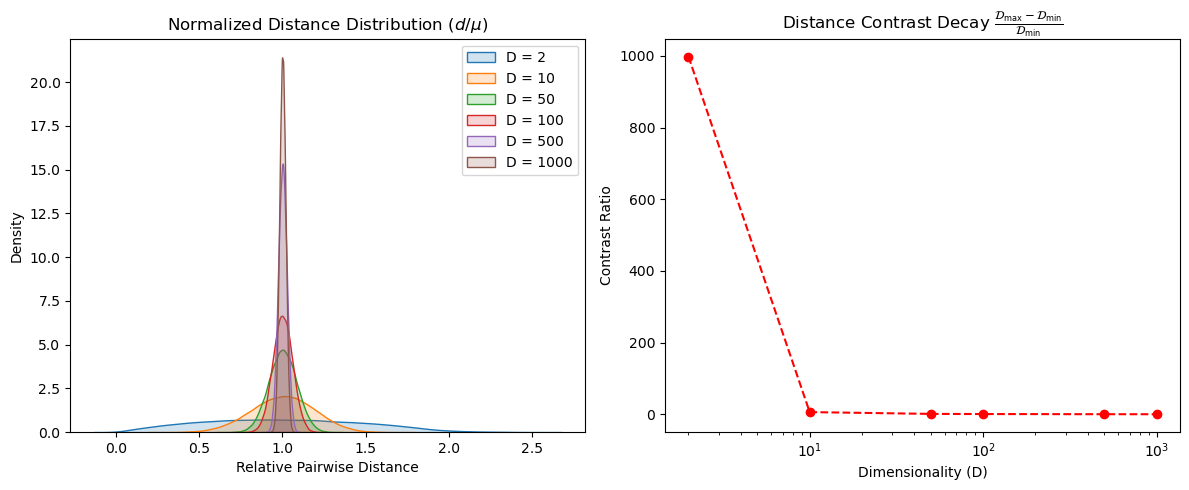

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist

# Set reproducibility seed
np.random.seed(42)

# Dimensions to evaluate (simulating increasing spectral resolution)
dimensions = [2, 10, 50, 100, 500, 1000]
num_samples = 500

# Dictionary to store distances per dimension
distance_stats = {}

for d in dimensions:
    # Simulate synthetic astronomical spectra normalized intensities in a hypercube
    synthetic_spectra = np.random.uniform(0, 1, size=(num_samples, d))
    
    # Compute pairwise Euclidean distances
    distances = pdist(synthetic_spectra, metric='euclidean')
    
    # Calculate the mathematical contrast: (Max - Min) / Min
    min_dist = np.min(distances)
    max_dist = np.max(distances)
    contrast = (max_dist - min_dist) / min_dist
    
    distance_stats[d] = {
        'distances': distances,
        'contrast': contrast,
        'mean': np.mean(distances),
        'std': np.std(distances)
    }

# Visualization of Distance Concentration
plt.figure(figsize=(12, 5))

# Plot 1: Variance of distances flattening out relative to the mean
plt.subplot(1, 2, 1)
for d in dimensions:
    sns.kdeplot(distance_stats[d]['distances'] / distance_stats[d]['mean'], label=f'D = {d}', fill=True, alpha=0.2)
plt.title("Normalized Distance Distribution ($d / \mu$)")
plt.xlabel("Relative Pairwise Distance")
plt.ylabel("Density")
plt.legend()

# Plot 2: Mathematical Contrast Decay
plt.subplot(1, 2, 2)
dims = list(distance_stats.keys())
contrasts = [distance_stats[d]['contrast'] for d in dims]
plt.plot(dims, contrasts, marker='o', linestyle='--', color='red')
plt.xscale('log')
plt.title("Distance Contrast Decay $\\frac{\\mathcal{D}_{\\max} - \\mathcal{D}_{\\min}}{\\mathcal{D}_{\\min}}$")
plt.xlabel("Dimensionality (D)")
plt.ylabel("Contrast Ratio")

plt.tight_layout()
plt.show()


# Quantifying Generalization Degradation under Covariate Shift

### Theoretical Framework
According to Statistical Learning Theory, a model minimizes Empirical Risk ($R_{\text{emp}}$) over the training sample distribution $P_{\text{train}}$. However, our actual target is to minimize Risk over the test distribution $P_{\text{test}}$. 

When $P_{\text{train}}(X) \neq P_{\text{test}}(X)$, the generalization error bound expands significantly. In this section, we train a non-linear estimator on the biased local sample (High SNR Catalog) and evaluate its structural failure on the deeper field population (Low SNR Sample), mathematically tracing the error divergence as a function of the feature space boundary mismatch.


=== Empirical Risk vs True Risk ===
Training Domain (Bright Catalog) - MSE: 0.0333 | MAE: 0.1455
Testing Domain (Deep Field Survey) - MSE: 0.0518 | MAE: 0.1796
Performance Degradation Factor: 1.55x increase in error metrics.


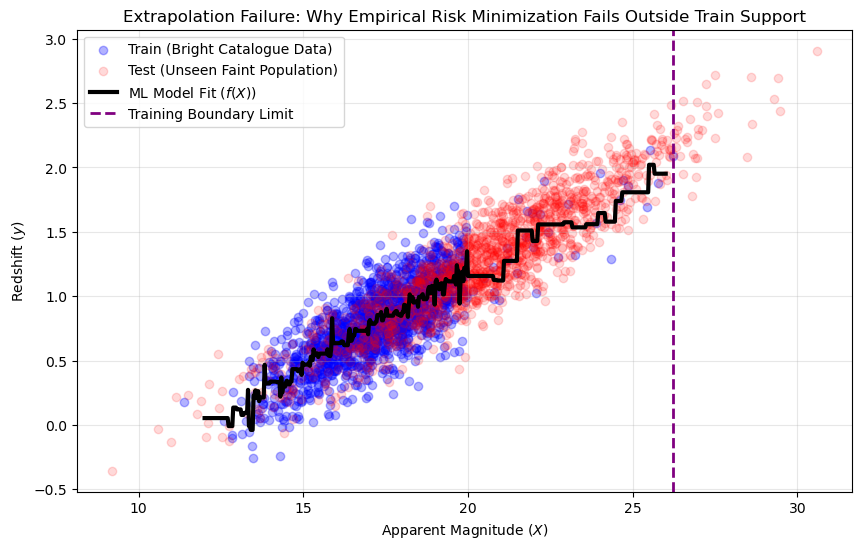

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set seed for independent block execution
np.random.seed(42)

# Re-generating the underlying distribution to prevent missing variable errors
total_pop_size = 10000
true_magnitude = np.random.normal(loc=20, scale=3, size=total_pop_size)
true_redshift = 0.15 * (true_magnitude - 12) + np.random.normal(0, 0.2, size=total_pop_size)

# Selection Bias Rule (Malmquist Bias simulation)
train_selection_prob = np.exp(-0.5 * ((true_magnitude - 16) / 2)**2)
train_selection_prob[true_magnitude > 20] = 0.01 
train_selection_prob /= train_selection_prob.sum()

train_indices = np.random.choice(total_pop_size, size=1500, p=train_selection_prob, replace=False)
test_indices = np.random.choice(np.setdiff1d(np.arange(total_pop_size), train_indices), size=1500, replace=False)

# Define X and y arrays and apply immediate reshaping for Scikit-Learn
X_train_arr = true_magnitude[train_indices].reshape(-1, 1)
y_train_arr = true_redshift[train_indices]

X_test_arr = true_magnitude[test_indices].reshape(-1, 1)
y_test_arr = true_redshift[test_indices]

# Initialize a flexible non-linear model (Gradient Boosting Regressor)
astron_regressor = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)

# Train exclusively on the biased bright catalog
astron_regressor.fit(X_train_arr, y_train_arr)

# Predict across both domains to capture the distribution divergence
preds_train = astron_regressor.predict(X_train_arr)
preds_test = astron_regressor.predict(X_test_arr)

# Calculate performance metrics demonstrating generalization breakdown
mse_train = mean_squared_error(y_train_arr, preds_train)
mse_test = mean_squared_error(y_test_arr, preds_test)
mae_train = mean_absolute_error(y_train_arr, preds_train)
mae_test = mean_absolute_error(y_test_arr, preds_test)

print(f"=== Empirical Risk vs True Risk ===")
print(f"Training Domain (Bright Catalog) - MSE: {mse_train:.4f} | MAE: {mae_train:.4f}")
print(f"Testing Domain (Deep Field Survey) - MSE: {mse_test:.4f} | MAE: {mae_test:.4f}")
print(f"Performance Degradation Factor: {mse_test / mse_train:.2f}x increase in error metrics.")

# Visualize the failure boundary of the ML estimator
plt.figure(figsize=(10, 6))
magnitude_grid = np.linspace(12, 26, 500).reshape(-1, 1)
model_curve = astron_regressor.predict(magnitude_grid)

plt.scatter(X_train_arr, y_train_arr, color='blue', alpha=0.3, label='Train (Bright Catalogue Data)')
plt.scatter(X_test_arr, y_test_arr, color='red', alpha=0.15, label='Test (Unseen Faint Population)')
plt.plot(magnitude_grid, model_curve, color='black', linewidth=3, linestyle='-', label='ML Model Fit ($f(X)$)')

plt.axvline(x=np.max(X_train_arr), color='purple', linestyle='--', linewidth=2, label='Training Boundary Limit')
plt.title("Extrapolation Failure: Why Empirical Risk Minimization Fails Outside Train Support")
plt.xlabel("Apparent Magnitude ($X$)")
plt.ylabel("Redshift ($y$)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()
